Why do we even need the Keras Functional Model?
Sequential model ❌ (limitation)

Sequential works only when:

One input ➜ one output

Layers are stacked linearly

Input → Dense → Dense → Output


But real models are often:

Multi-input

Multi-output

With branches, skips, merges

👉 Sequential model can’t handle this

2️⃣ What is the Keras Functional Model?

The Functional API lets you build graphs of layers, not just stacks.

Each layer is treated like a function:

output = layer(input)


This allows:

Branching

Merging

Skip connections (ResNet style)

Non-linear architectures

3️⃣ Basic Syntax (Core Idea)
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(10,))
x = Dense(32, activation='relu')(inputs)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)


🧠 Key rule to remember:

Every layer is called on a tensor, not added.

4️⃣ What does “Non-Linear Neural Network” mean here?

⚠️ Important clarification:

Activation functions make networks mathematically non-linear

Functional API enables structural non-linearity

Structural non-linearity means:

One layer feeds into multiple layers

Multiple paths merge together

Information flows in complex ways

5️⃣ Example 1: Branching Network (Non-Linear Flow)
Architecture:
        → Dense(32) →
Input →                  → Concatenate → Output
        → Dense(64) →

Code:
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

inputs = Input(shape=(20,))

branch1 = Dense(32, activation='relu')(inputs)
branch2 = Dense(64, activation='relu')(inputs)

merged = Concatenate()([branch1, branch2])
outputs = Dense(1, activation='sigmoid')(merged)

model = Model(inputs, outputs)


✔️ This is impossible with Sequential

6️⃣ Example 2: Skip Connection (ResNet Idea)
Architecture:
Input → Dense → Dense
   ↘────────────↗

Code:
from tensorflow.keras.layers import Add

inputs = Input(shape=(10,))
x = Dense(64, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)

skip = Add()([inputs, x])
outputs = Dense(1)(skip)

model = Model(inputs, outputs)


🧠 Why useful?

Solves vanishing gradient

Helps deep networks learn better

7️⃣ Example 3: Multiple Inputs (Very common IRL)
image_input = Input(shape=(224,224,3))
meta_input = Input(shape=(10,))

x1 = Dense(64, activation='relu')(Flatten()(image_input))
x2 = Dense(32, activation='relu')(meta_input)

merged = Concatenate()([x1, x2])
output = Dense(1, activation='sigmoid')(merged)

model = Model([image_input, meta_input], output)


✔️ Used in:

Medical AI

Recommendation systems

Multimodal learning

8️⃣ When should YOU use Functional API?

| Use Case                  | API        |
| ------------------------- | ---------- |
| Simple stack              | Sequential |
| CNN with pretrained model | Functional |
| Transfer Learning         | Functional |
| Multiple inputs           | Functional |
| Skip connections          | Functional |


Since you’re learning CNNs + Transfer Learning,
Functional API is your default choice now.

9️⃣ Mental Model (Easy to remember)

Think of:

Layers = Lego blocks

Functional API = wiring those blocks freely

Sequential = straight line
Functional = full circuit board ⚡

🔟 Common Mistakes (Avoid these)

❌ Forgetting Input()
❌ Using .add() instead of calling layers
❌ Mixing Sequential & Functional wrongly
❌ Shape mismatch in merging layers


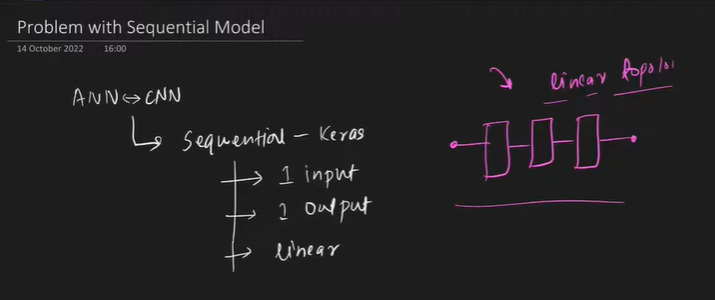

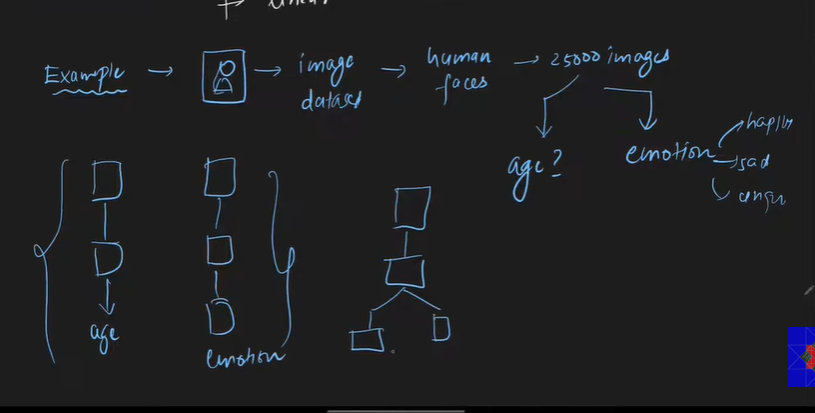

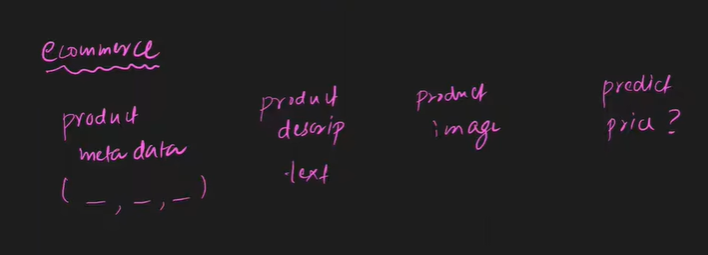

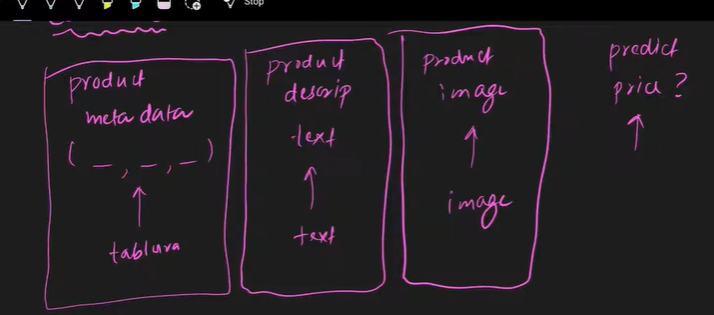

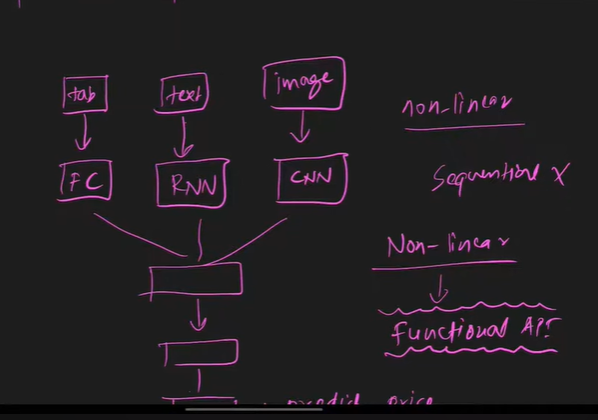

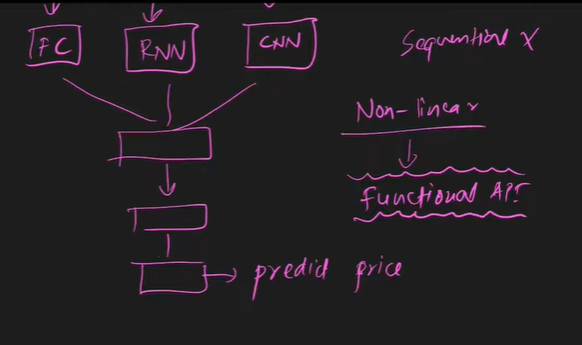

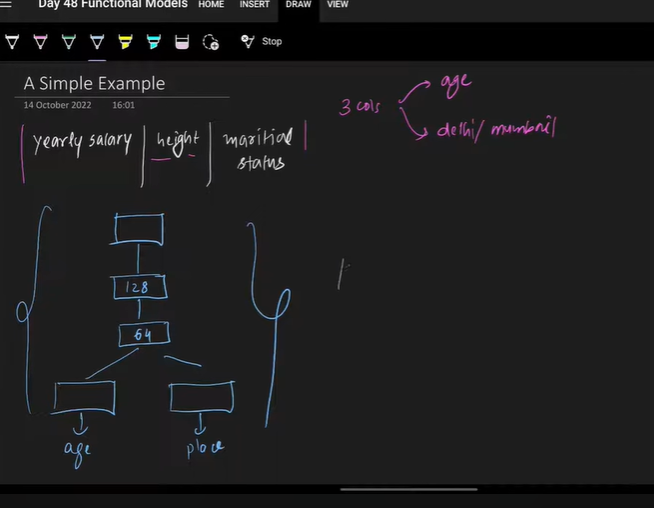

https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbE50OElSUUpOTS01Y2lmZ1hOMG5kMDlGR2c2QXxBQ3Jtc0tuM2tXdGozV3BsVjlqbFFyWTV2R3FGUGFZTThUOGo5RkY0TE1kUmJXLXhtSWtwWllwX3FFNVZoNEhEeEwwcUZxVWV3el9ZcnY1WVd6cDZjbXY5Wk9pUFY3bnZ4UTZBLW1zQ3RpMHlnQUxqVUNtcTV1VQ&q=https%3A%2F%2Fcolab.research.google.com%2Fdrive%2F1uCHf6hoLR1a-46RznVjqnhVZNechF0fz%3Fusp%3Dsharing&v=OvQQP1QVru8


https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbjY4cTlDMjZ6dFpaQjJJWElOLVRSb1BRX0ZZZ3xBQ3Jtc0tsM2lDRXdtNzVSalNGbFhORVBUMkl3dFJadjBHdWZ1clJRdlBVSEJ5RTQzWWRlbnlhelJmQWROYkVvNlplZFN5WXBWYVp6VXg2Q1ZxWml1MTFrRGxaa2d6Y2tHdGxfckdqT3Rvdm9ONzNhYU90YVJlYw&q=https%3A%2F%2Fcolab.research.google.com%2Fdrive%2F1pKfnYBal9HhuwRADU0FrWaVJ11_llk8-%3Fusp%3Dsharing&v=OvQQP1QVru8


https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbGdkckJxcG9lT1NJaC0wWDNYOEJGdFlIZm1tQXxBQ3Jtc0ttUndZYW94ZmxMTjU1RURsdWR6ZHdKdkVSYnpHelpjOE5yNGRPemZFd1YwUjNZNGdYMUN3Q0ZyOEM5QzNEdlJxSEY4QS1wX3U3MEpRcklROWpHR2s2M0xiS3dPTVhGVnI1RkZLOXpVaHk4S0dhS1pVSQ&q=https%3A%2F%2Fcolab.research.google.com%2Fdrive%2F1B2azaSX9g55olY473c7WAMf3E5-717Ge%3Fusp%3Dsharing&v=OvQQP1QVru8

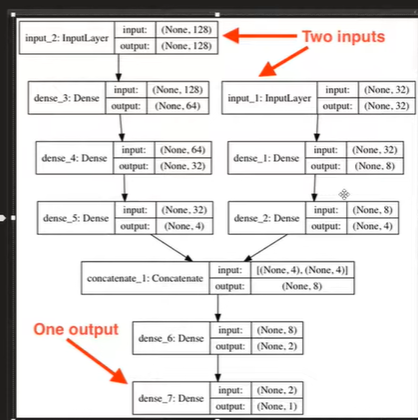

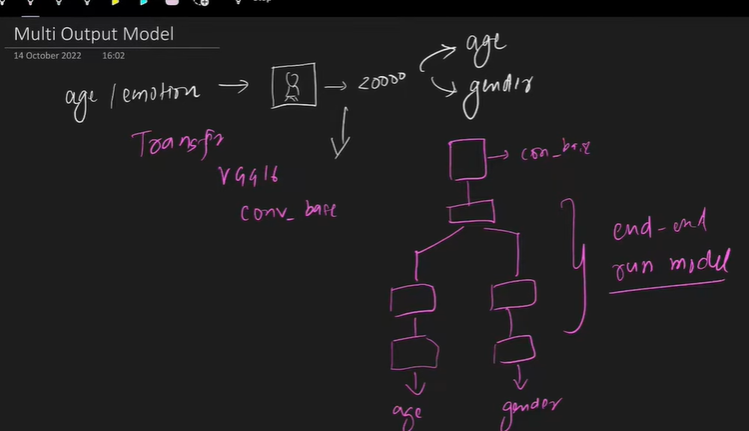